# Lab 1

**Name:** Arden Diago
**Reg No:** 2547112
**Class:** MCA - A

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [24]:
DATA1='/home/arden/Coding/ML-Class-Work/data/city_day.csv'
DATA2='/home/arden/Coding/ML-Class-Work/data/crop_production.csv'

In [25]:
def display_details(title, d1, d2):
    print(f" *** {title} ***")
    print(f"Data 1:\n{d1}\n\nData 2:\n{d2}")

In [26]:
df1 = pd.read_csv(DATA1)
df2 = pd.read_csv(DATA2)

# print(f"* Data 1\n\n{df1.head()}\n\n* Data 2\n\n{df2.head()}")
display_details("Displaying the first 5 rows of the dataset", df1.head(), df2.head())

 *** Displaying the first 5 rows of the dataset ***
Data 1:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Data 2:
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS    

# Task 1 — Dataset Inspection and Profiling

For each dataset:

* 
* Identify the number of rows and columns
* Examine column names and data types
* Identify missing values
* Detect duplicate records
* Review summary statistics
* Inspect categorical values and possible inconsistencies

### Analyze the dataset structure

In [32]:
# info of dataset 1
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [33]:
# info of dataset 2
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 13.1 MB


In [37]:
display_details("Missing Values", df1.isna().sum(), df2.isna().sum())

 *** Missing Values ***
Data 1:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Data 2:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


#### Getting Categorical Values insights

In [49]:
def categorical_insights(column_name, d):
    print(f"Unique Values: \n{d[column_name].unique()} \n\n\nNo of rows: \n{d[column_name].unique().shape}")

In [51]:
categorical_insights("AQI_Bucket", df1)

Unique Values: 
<StringArray>
[nan, 'Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory', 'Good']
Length: 7, dtype: str 


No of rows: 
(7,)


In [52]:
categorical_insights("District_Name", df2)

Unique Values: 
<StringArray>
[                'NICOBARS', 'NORTH AND MIDDLE ANDAMAN',
           'SOUTH ANDAMANS',                'ANANTAPUR',
                 'CHITTOOR',            'EAST GODAVARI',
                   'GUNTUR',                   'KADAPA',
                  'KRISHNA',                  'KURNOOL',
 ...
           'DINAJPUR UTTAR',                  'HOOGHLY',
                   'HOWRAH',               'JALPAIGURI',
                   'MALDAH',           'MEDINIPUR EAST',
           'MEDINIPUR WEST',              'MURSHIDABAD',
                    'NADIA',                  'PURULIA']
Length: 646, dtype: str 


No of rows: 
(646,)


In [54]:
categorical_insights("Season", df2)

Unique Values: 
<StringArray>
['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ',
 'Winter     ']
Length: 6, dtype: str 


No of rows: 
(6,)


In [55]:
categorical_insights("Crop", df2)

Unique Values: 
<StringArray>
[           'Arecanut', 'Other Kharif pulses',                'Rice',
              'Banana',           'Cashewnut',            'Coconut ',
          'Dry ginger',           'Sugarcane',        'Sweet potato',
             'Tapioca',
 ...
         'Ribed Guard',                 'Yam',               'Apple',
               'Peach',                'Pear',               'Plums',
              'Litchi',                 'Ber',     'Other Dry Fruit',
        'Jute & mesta']
Length: 124, dtype: str 


No of rows: 
(124,)


# Insights of this Task 1

The **Dataset 1** contains 13 columns with float 64 data type and 3 columns with string datatype. this datatypes support the dataset for the City AQI. we see a huge increase in the number of missing values in this dataset. i took categorical insights on column names such as **AQI_Bucket**.

The **Dataset 2** we see 2 columns with float 64 data type, one integer 64, and four string data type data in it. This data set gives us insights on the crops that were grown, over the years and the area. the missing dataset has compratively less missing values.  i took categorical insights on column names such as **District_Name**, **Season**, and **Crop**.

# Task 2 — Missing Value Treatment

## Requirements

For every column containing missing values:

* Decide whether to:

  * Remove the column
  * Remove affected rows
  * Impute missing values
* Justify why the chosen method is appropriate for that specific column


In [64]:
def dataset_insights(df):

    # Numeric Columns
    numeric_df = df.select_dtypes(include='number')

    # Categorical Columns
    categorical_df = df.select_dtypes(exclude='number')

    print("========== NUMERICAL DATA ==========\n")

    if not numeric_df.empty:

        print("Mean:\n")
        print(numeric_df.mean())

        print("\nMedian:\n")
        print(numeric_df.median())

        print("\nMode:\n")
        print(numeric_df.mode())

        print("\nStandard Deviation:\n")
        print(numeric_df.std())

        print("\nVariance:\n")
        print(numeric_df.var())

        print("\nMinimum Values:\n")
        print(numeric_df.min())

        print("\nMaximum Values:\n")
        print(numeric_df.max())

        print("\nQuartiles:\n")
        print(numeric_df.quantile([0.25, 0.5, 0.75]))

    else:
        print("No numerical columns found.")

    print("\n\n========== CATEGORICAL DATA ==========\n")

    if not categorical_df.empty:

        for col in categorical_df.columns:

            print(f"\nColumn: {col}")

            print("\nUnique Values:")
            print(categorical_df[col].unique())

            print("\nFrequency Count:")
            print(categorical_df[col].value_counts())

            print("\nMode:")
            print(categorical_df[col].mode())

            print("\nNumber of Unique Values:")
            print(categorical_df[col].nunique())

            print("\n-----------------------------")

    else:
        print("No categorical columns found.")

In [66]:
dataset_insights(df1)

========== NUMERICAL DATA ==========

Mean:

PM2.5       67.450578
PM10       118.127103
NO          17.574730
NO2         28.560659
NOx         32.309123
NH3         23.483476
CO           2.248598
SO2         14.531977
O3          34.491430
Benzene      3.280840
Toluene      8.700972
Xylene       3.070128
AQI        166.463581
dtype: float64

Median:

PM2.5       48.57
PM10        95.68
NO           9.89
NO2         21.69
NOx         23.52
NH3         15.85
CO           0.89
SO2          9.16
O3          30.84
Benzene      1.07
Toluene      2.97
Xylene       0.98
AQI        118.00
dtype: float64

Mode:

   PM2.5  PM10    NO    NO2  NOx   NH3   CO   SO2     O3  Benzene  Toluene  \
0   11.0  94.0  5.93  10.58  0.0  6.29  0.0  5.74  16.48      0.0      0.0   

   Xylene    AQI  
0     0.0  102.0  

Standard Deviation:

PM2.5       64.661449
PM10        90.605110
NO          22.785846
NO2         24.474746
NOx         31.646011
NH3         25.684275
CO           6.962884
SO2         18.1

In [67]:
dataset_insights(df2)

========== NUMERICAL DATA ==========

Mean:

Crop_Year       2005.643018
Area           12002.820864
Production    582503.442251
dtype: float64

Median:

Crop_Year     2006.0
Area           582.0
Production     729.0
dtype: float64

Mode:

   Crop_Year  Area  Production
0       2003   1.0         1.0

Standard Deviation:

Crop_Year     4.952164e+00
Area          5.052340e+04
Production    1.706581e+07
dtype: float64

Variance:

Crop_Year     2.452393e+01
Area          2.552614e+09
Production    2.912420e+14
dtype: float64

Minimum Values:

Crop_Year     1997.00
Area             0.04
Production       0.00
dtype: float64

Maximum Values:

Crop_Year     2.015000e+03
Area          8.580100e+06
Production    1.250800e+09
dtype: float64

Quartiles:

      Crop_Year    Area  Production
0.25     2002.0    80.0        88.0
0.50     2006.0   582.0       729.0
0.75     2010.0  4392.0      7023.0


========== CATEGORICAL DATA ==========


Column: State_Name

Unique Values:
<StringArray>
['Andaman 

# PDF (Probibility Distribution Function)

In [70]:
def pdf(column, df):
    mean = df[column].mean()
    std = df[column].std()

    x = np.linspace(df[column].min(),
                df[column].max(),
                100)

    pdf = norm.pdf(x, mean, std)

    plt.plot(x, pdf)

    plt.title(f"PDF of {column}")
    plt.xlabel(f"{column}")
    plt.ylabel("Density")

    plt.show()

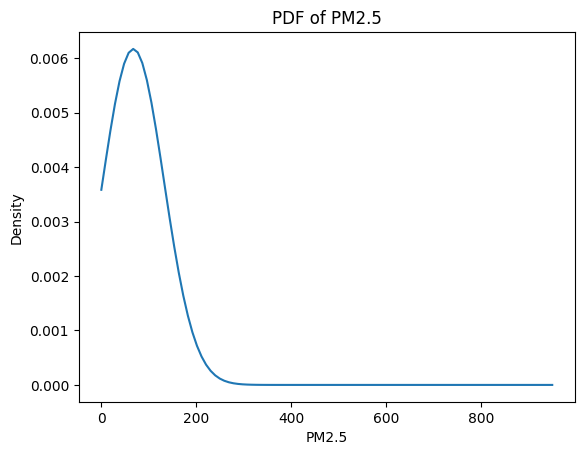

In [71]:
pdf("PM2.5", df1)

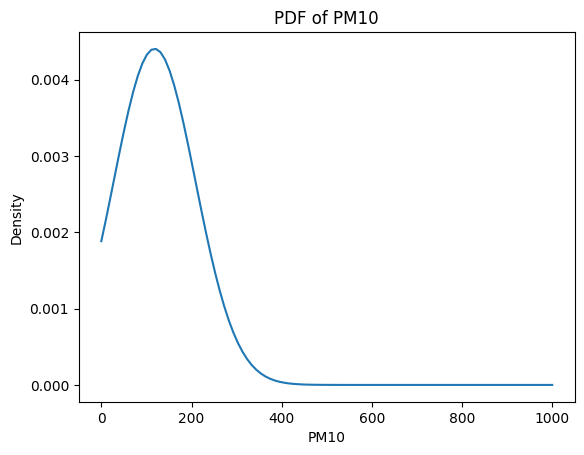

In [72]:
pdf("PM10",df1)